In [68]:
# conda activate anndata

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

In [31]:
mapping_df = pd.read_csv("data/janssens_2025_preprint_RNA_vs_ADT_corr_meanExpr.csv")

In [44]:
mapping_df.head()

,Protein,Gene,Cor,Mean_RNA_expr
0,4-1BB,Tnfrsf9,-0.014476,0.075514
1,CD102,Icam2,0.047848,0.010010
2,CD103,Itgae,0.058444,0.080188
3,CD105,Eng,-0.001613,0.002625
4,CD106,Vcam1,0.074976,0.255781


## Subset author data to eLNP cells

In [45]:
# Get cells of interest 
adata = ad.read_h5ad("data/janssens_2025_CellRanger_Velocyto_counts_eLNP.h5ad")

In [46]:
adata.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,sum,detected,subsets_Mito_sum,subsets_Mito_detected,subsets_Mito_percent,subsets_RBC_sum,subsets_RBC_detected,...,newClustersTmp,newClusters,annotated_clusters_paper_2024,annotated_clusters_Muscat_paper_2024,annotated_clusters_Muscat_v2_paper_2024,newClusters_paper_2024,Cell_ID,_scvi_batch,_scvi_labels,Experimental_condition
CellID,,,,,,,,,,,,,,,,,,,,,
AAAGGGCTCTGAGCAT-6,VBO009,7549,2074,7549,2074,143,9,1.894291,0,0,...,Immature cDC1s,Immature cDC1s_eLNPs_2h,Immature cDC1s,Immature cDC1s,eLNPs_2h_Immature cDC1s,Immature cDC1s_eLNPs_2h,AAAGGGCTCTGAGCAT-6,0,0,eLNP
AAACCCAAGGGAGTTC-6,VBO009,7461,1732,7461,1732,122,10,1.635170,0,0,...,Late mature cDC1s,Late mature cDC1s_eLNPs_2h,Tmem176+ late mature cDC1s,Late mature cDC1s,eLNPs_2h_Late mature cDC1s,Late mature cDC1s_eLNPs_2h,AAACCCAAGGGAGTTC-6,0,0,eLNP
AAAGGATTCACCCTCA-6,VBO009,6795,1923,6795,1923,86,8,1.265636,0,0,...,Immature cDC1s,Immature cDC1s_eLNPs_2h,Immature cDC1s,Immature cDC1s,eLNPs_2h_Immature cDC1s,Immature cDC1s_eLNPs_2h,AAAGGATTCACCCTCA-6,0,0,eLNP
AAAGGTATCTCTCGAC-6,VBO009,4724,1717,4724,1717,91,11,1.926334,0,0,...,Immature cDC1s,Immature cDC1s_eLNPs_2h,Immature cDC1s,Immature cDC1s,eLNPs_2h_Immature cDC1s,Immature cDC1s_eLNPs_2h,AAAGGTATCTCTCGAC-6,0,0,eLNP
AAACGAACAACAAAGT-6,VBO009,7076,1919,7076,1919,151,10,2.133974,0,0,...,Early mature cDC1s,Early mature cDC1s_eLNPs_2h,Il12b+ cDC1s,Early mature cDC1s,eLNPs_2h_Early mature cDC1s,Early mature cDC1s_eLNPs_2h,AAACGAACAACAAAGT-6,0,0,eLNP


In [47]:
author_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_subset.csv", index_col=0)
author_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_subset.csv", index_col=0)

In [48]:
author_ADT.index = author_ADT.index.str.replace("-1", "", regex=False)
author_ADT.index = author_ADT.index.str.replace("_", "-", regex=False)

author_RNA.index = author_RNA.index.str.replace("-1", "", regex=False)
author_RNA.index = author_RNA.index.str.replace("_", "-", regex=False)

In [49]:
print(author_ADT.index.isin(adata.obs.index).sum())
print(author_RNA.index.isin(adata.obs.index).sum())

21327
21327


In [50]:
author_ADT = author_ADT.loc[adata.obs.index]
author_RNA = author_RNA.loc[adata.obs.index]

In [51]:
np.all(author_ADT.index == adata.obs.index)
# np.all(author_RNA.index == adata.obs.index)

True

## Calculate correlation between RNA and protein

In [52]:
author_RNA.shape

(21327, 187)

In [53]:
author_ADT.shape

(21327, 187)

In [55]:
author_ADT.T

CellID,AAAGGGCTCTGAGCAT-6,AAACCCAAGGGAGTTC-6,AAAGGATTCACCCTCA-6,AAAGGTATCTCTCGAC-6,AAACGAACAACAAAGT-6,AAACGAACAATTGTGC-6,AAACGAACAACTTGCA-6,AAAGGTATCAGGACGA-6,AAACGAATCCGCAGTG-6,AAAGGTAAGAATCGAT-6,...,TTTGACTTCTTCCGTG-2,TTTGGTTTCGTCTAAG-2,TTTGTTGAGTAAGAGG-2,TTTGGTTTCATCGCCT-2,TTTGGTTGTTTGGGTT-2,TTTGGAGGTCTCACGG-2,TTTGGAGTCGACGTCG-2,TTTGGAGCACAAGTTC-2,TTTGTTGTCACCATCC-2,TTTGGTTGTGGATACG-2
4-1BB,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CD102,1,0,0,0,1,0,0,0,1,1,...,1,3,0,0,0,0,0,1,0,0
CD103,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
CD105,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CD106,1,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TLR4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
JAML,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DLL1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENPP1,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
author_ADT_rename = author_ADT.copy()
author_ADT_rename.columns = author_RNA.columns

In [67]:
corrs = author_ADT_rename.corrwith(author_RNA)

In [75]:
author_RNA['Trbv5'].corr(author_ADT['TCRb5'])

/mnt/lareaulab/reliscu/anaconda3/envs/anndata/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/lareaulab/reliscu/anaconda3/envs/anndata/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


nan

In [80]:
mapping_df.loc[mapping_df['Gene'].isin(["Trbv8"])]

,Protein,Gene,Cor,Mean_RNA_expr
138,TCRb8,Trbv8,NaN,0.0


In [78]:
corrs

Tnfrsf9   -0.006563
Icam2      0.037857
Itgae      0.063608
Eng       -0.004979
Vcam1      0.053343
             ...   
Tlr4      -0.006576
Jaml       0.058070
Dll1      -0.005245
Enpp1      0.001404
Cd2        0.009499
Length: 187, dtype: float64

In [83]:
corrs.sort_values(ascending=False).head(n=30)

Cd63       0.414139
Cd8b1      0.348518
Sell       0.292543
Itgax      0.270695
Ly6e       0.243426
Kit        0.224760
Timd4      0.216021
Itgal      0.180021
Cd4        0.172216
Cd8a       0.172075
Itga2      0.163752
Lamp1      0.147007
Fas        0.128160
Cd9        0.119076
Cd274      0.117043
Clec12a    0.107615
Cd1d1      0.106436
Procr      0.103137
Cd80       0.096585
Ly6a       0.095552
Icos       0.093864
Havcr2     0.092973
Cd24a      0.091860
Cd48       0.088260
Il2ra      0.078081
Bst2       0.077355
Spn        0.068233
Itgae      0.063608
Cd83       0.059979
Jaml       0.058070
dtype: float64

(array([  5., 110.,  23.,  12.,   4.,   2.,   3.,   1.,   1.,   1.]),
 array([-0.06162414, -0.01404779,  0.03352856,  0.0811049 ,  0.12868125,
         0.1762576 ,  0.22383395,  0.2714103 ,  0.31898665,  0.366563  ,
         0.41413935]),
 <BarContainer object of 10 artists>)

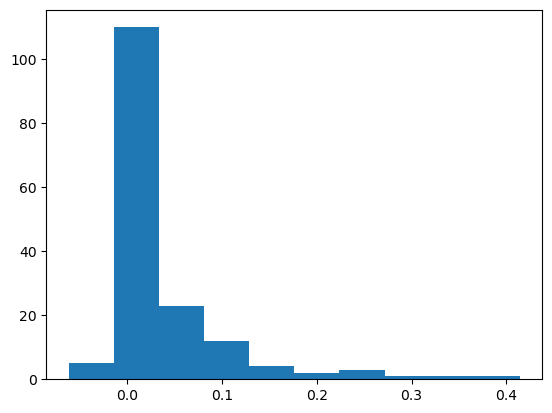

In [69]:
plt.hist(corrs)